In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import statistics as st
from sklearn.preprocessing import OneHotEncoder as ohe
from sklearn import preprocessing

In [2]:
dat = pd.read_csv(r"E:\DATA FOR TEST\New Churn Data\Churn_Modelling_0.csv")
data = dat.copy()

In [3]:
print(data.info())
print(data.describe())
print(data.isnull().sum())
data.head()
data.drop(columns = ["CustomerId", "RowNumber", "Surname"], axis = 1, inplace = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

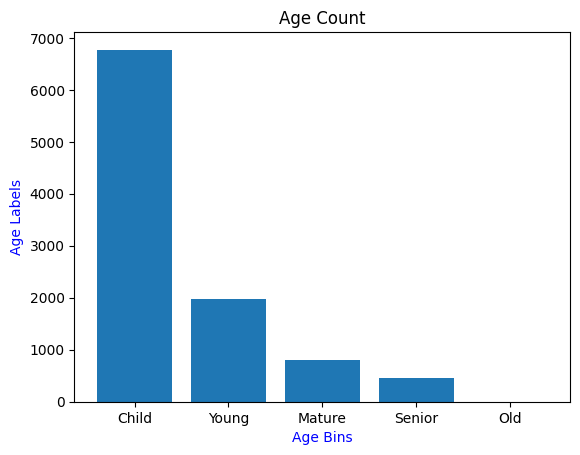

In [10]:
# Feature Binning
bins = [0, 16, 30, 50, 60, 100]
labels = ["Child", "Young", "Mature", "Senior", "Old"]
data["Age Group"] = pd.cut(data.Age, labels =  labels, bins = bins, include_lowest=True)
# data[["Age Group", "Age"]].head(30)
# print(data["Age Group"].value_counts(), data["Age Group"].value_counts()/len(data["Age Group"])*100) # Each Value Count

# Visulization
plt.bar(labels, data["Age Group"].value_counts())
plt.title("Age Count")
plt.xlabel("Age Bins", color = "Blue")
plt.ylabel("Age Labels", color = "Blue")
plt.show()

In [5]:
# Feature Encoding
data["location"] = data.Geography.map({"France" : 0, "Germany" : 1, "Spain" : -1}) # Converting Locations in Ternnary

In [6]:
# By One Hot Encoding
categorical_data = data.select_dtypes(include=["object", "category"])
encoder = ohe()

# Get Dummies
one_hot = pd.get_dummies(data["Gender"], dtype = int)
one_hot


,Female,Male
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
...,...,...
9995,0,1
9996,0,1
9997,1,0
9998,0,1


In [7]:
# Label Encoding
le = preprocessing.LabelEncoder()
data["Gender_label"] = le.fit_transform(data.Gender.values)

# By Chat Gpt

In [23]:
# 1. Create a simple dataset
df = pd.DataFrame({'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [14, 22, 45, 12, 50],
    'Gender': ['Female', 'Male', 'Male', 'Male', 'Female']})

# Goal: Turn Age (Number) into Age_Group (Category)  Feature Binning
# Bins is always Extra 1
bins = [0, 18, 35, 100]
labels = ['Child', 'Adult', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Goal: Turn Gender (Text) into Numbers (0 and 1) Feature Encoding
df['Gender_Encoded'] = df['Gender'].map({'Female': 0, 'Male': 1})

print(df)

      Name  Age  Gender Age_Group  Gender_Encoded
0    Alice   14  Female     Child               0
1      Bob   22    Male     Adult               1
2  Charlie   45    Male    Senior               1
3    David   12    Male     Child               1
4      Eve   50  Female    Senior               0


In [11]:
# Sample Data: Notice '1000' is an outlier
data = [10, 12, 15, 18, 20, 22, 1000] 
df = pd.DataFrame(data, columns=['Price'])

# 1. Equal Width (Divides range 10-1000 into 3 equal parts)
# Result: Most data goes into the first bin; last bins are empty/sparse.
df['Equal_Width'] = pd.cut(df['Price'], bins=3)

# 2. Equal Frequency (Divides into 3 groups with equal counts)
# Result: It forces ~2 items into each bin, regardless of the values.
df['Equal_Freq'] = pd.qcut(df['Price'], q=3)

print(df)

   Price      Equal_Width      Equal_Freq
0     10    (9.01, 340.0]   (9.999, 15.0]
1     12    (9.01, 340.0]   (9.999, 15.0]
2     15    (9.01, 340.0]    (15.0, 20.0]
3     18    (9.01, 340.0]    (15.0, 20.0]
4     20    (9.01, 340.0]    (15.0, 20.0]
5     22    (9.01, 340.0]  (20.0, 1000.0]
6   1000  (670.0, 1000.0]  (20.0, 1000.0]
